<a href="https://colab.research.google.com/github/nikamade/Data201/blob/main/DATA201_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# DATA 201 Final Project  
# The Model Comparaison: One Tree vs. Many Trees

## Predicting Crime Victims in Montgomery County

 Name: Monique Madinko Epse Kamgui

This project compares:
- Decision Tree
- Random Forest
- Gradient Boosting

The goal is to predict the number of victims in crime incidents using crime data from Montgomery County, Maryland.



# 1. Introduction

This project analyzes the Crime Incidents dataset from Montgomery County, Maryland. This dataset contains records of crimes reported to the Montgomery County Police Department. It includes details such as the type of crime, the location, and the number of victims involved in each incident.The main goal of this project is to build machine learning models to predict the number of victims for a specific incident. By using variables like the crime category and the location, I want to see if the models can accurately estimate how many people are affected by different types of crimes. This topic is personally very important to me because I currently live in the DMV (DC, Maryland, Virginia) region. As I am planning to relocate soon to a new area within Maryland or a nearby state, safety is a top priority for my family. Understanding crime patterns helps me, as a resident and a parent, to evaluate different neighborhoods. For the community and the police, this information is vital to understand which areas or types of crimes result in more victims. It helps local governments allocate resources effectively to improve emergency services and, ultimately, to keep residents like myself and my neighbors safe in our daily lives There are some limitations in this data. First, many crimes are never reported to the police(because neighborhood are more friendly), second some area can have more police patrol than other, also may some police work better than other.

Source:
Montgomery County Government. (2026). Crime Incidents. Montgomery County Open Data Portal. https://data.montgomerycountymd.gov/api/views/icn6-v9z3/rows.csv?accessType=DOWNLOAD


## Load Libraries and Upload the Dataset


In [23]:

import pandas as pd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://data.montgomerycountymd.gov/api/views/icn6-v9z3/rows.csv?accessType=DOWNLOAD"

df = pd.read_csv(url , low_memory=False)

df.head()


,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Start_Date_Time,End_Date_Time,NIBRS Code,Victims,Crime Name1,Crime Name2,...,PRA,Address Number,Street Prefix,Street Name,Street Suffix,Street Type,Latitude,Longitude,Police District Number,Location
0,201194204,2305,180031343,06/25/2018 07:03:12 PM,06/22/2018 06:00:00 PM,06/22/2018 08:00:00 PM,23F,1,Crime Against Property,Theft From Motor Vehicle,...,546,19200.0,NaN,WATKINS MILL,NaN,RD,39.17057,-77.2089,6D,"(39.1706, -77.2089)"
1,201192754,3562,180029527,06/15/2018 09:28:52 AM,06/15/2018 09:28:00 AM,06/15/2018 09:28:00 AM,35A,1,Crime Against Society,Drug/Narcotic Violations,...,391,17000.0,NaN,BATCHELLORS FOREST,NaN,RD,39.13580,-77.0453,4D,"(39.1358, -77.0453)"
2,201197266,5404,180035053,07/15/2018 10:14:12 PM,07/15/2018 10:14:00 PM,07/15/2018 11:45:00 PM,90D,1,Crime Against Society,Driving Under the Influence,...,336,NaN,NaN,WELLER,NaN,RD,39.06421,-77.0690,4D,"(39.0642, -77.069)"
3,201197538,2399,180035451,07/17/2018 10:11:04 PM,07/17/2018 01:40:00 PM,07/17/2018 02:20:00 PM,23H,1,Crime Against Property,All other Larceny,...,594,NaN,NaN,CLOPPER,NaN,RD,39.14830,-77.2377,5D,"(39.1483, -77.2377)"
4,201194239,1399,180031372,06/25/2018 10:14:39 PM,06/25/2018 10:14:00 PM,NaN,13B,1,Crime Against Person,Simple Assault,...,447,12600.0,NaN,GREY EAGLE,NaN,CT,39.16706,-77.2635,5D,"(39.1671, -77.2635)"


# 2. Dataset and Preparation

In [24]:

df.shape

(492164, 30)

In [25]:
df.describe()

,Incident ID,CR Number,Victims,Zip Code,Address Number,Latitude,Longitude
count,4.921640e+05,4.921640e+05,492164.000000,488716.000000,4.534880e+05,492164.000000,492164.000000
mean,2.013286e+08,1.956170e+08,1.021816,20876.703795,8.351806e+03,37.313921,-73.627079
std,1.405746e+05,6.004226e+07,0.184530,135.231517,1.553406e+04,8.122051,16.025952
min,2.010871e+08,1.001107e+07,1.000000,6.000000,0.000000e+00,0.000000,-77.516700
25%,2.012073e+08,1.800473e+08,1.000000,20853.000000,1.600000e+03,39.015232,-77.196525
50%,2.013262e+08,2.100121e+08,1.000000,20878.000000,8.100000e+03,39.069520,-77.098400
75%,2.014494e+08,2.300613e+08,1.000000,20904.000000,1.240000e+04,39.140770,-77.026700
max,2.015751e+08,2.600782e+08,22.000000,29882.000000,2.090600e+06,39.351240,0.000000





The dataset has 30 variables total but I will work with these 4 variables:



and the target variable for this project is **Victims**.



In [26]:
import pandas as pd

# 1. description of data
data_desc = {
    "Variable Name": ["Crime Name2", "Police District Name", "City", "Victims"],
    "Description": [
        "The category of the crime.",
        "The name of the police station area where the incident occurred.",
        "The city where the crime took place.",
        "The total number of victims in the incident."
    ],
    "Type": ["Categorical", "Categorical", "Categorical", "Quantitative"]
}

# 2. Création du DataFrame
df_desc = pd.DataFrame(data_desc)
df_desc


,Variable Name,Description,Type
0,Crime Name2,The category of the crime.,Categorical
1,Police District Name,The name of the police station area where the ...,Categorical
2,City,The city where the crime took place.,Categorical
3,Victims,The total number of victims in the incident.,Quantitative


In [27]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492164 entries, 0 to 492163
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Incident ID             492164 non-null  int64  
 1   Offence Code            492164 non-null  object 
 2   CR Number               492164 non-null  int64  
 3   Dispatch Date / Time    420883 non-null  object 
 4   Start_Date_Time         492164 non-null  object 
 5   End_Date_Time           219544 non-null  object 
 6   NIBRS Code              492164 non-null  object 
 7   Victims                 492164 non-null  int64  
 8   Crime Name1             492164 non-null  object 
 9   Crime Name2             492164 non-null  object 
 10  Crime Name3             492164 non-null  object 
 11  Police District Name    490670 non-null  object 
 12  Block Address           453347 non-null  object 
 13  City                    492127 non-null  object 
 14  State               

In [28]:

# Select my columns

data = df[['Victims',
           'Crime Name1',
           'Police District Name',
           'City']]

data.head()


,Victims,Crime Name1,Police District Name,City
0,1,Crime Against Property,MONTGOMERY VILLAGE,MONTGOMERY VILLAGE
1,1,Crime Against Society,WHEATON,OLNEY
2,1,Crime Against Society,WHEATON,SILVER SPRING
3,1,Crime Against Property,GERMANTOWN,GERMANTOWN
4,1,Crime Against Person,GERMANTOWN,GERMANTOWN


In [29]:

# Remove missing values

data_clean = data.dropna()

data_clean.shape


(490655, 4)

In [30]:

# Encode categorical variables

data_encoded = pd.get_dummies(data_clean, drop_first=True)

data_encoded.head()


,Victims,Crime Name1_Crime Against Person,Crime Name1_Crime Against Property,Crime Name1_Crime Against Society,Police District Name_GERMANTOWN,Police District Name_MONTGOMERY VILLAGE,Police District Name_OTHER,Police District Name_ROCKVILLE,Police District Name_SILVER SPRING,Police District Name_TAKOMA PARK,...,City_TAKOMS PARK,City_TP,City_VALLEYWOOD,City_WASHINGTON,City_WASHINGTON GROVE,City_WEATON,City_WEHATON,City_WHEATON,City_WHITE OAK,City_WOODBINE
0,1,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,True,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



# 3. Exploratory Data Analysis

## Bargraph of Total Victims by Crime Category:


/tmp/ipykernel_7421/88865775.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Crime Name1', y='Victims', data=data_clean, estimator=sum, palette='viridis')


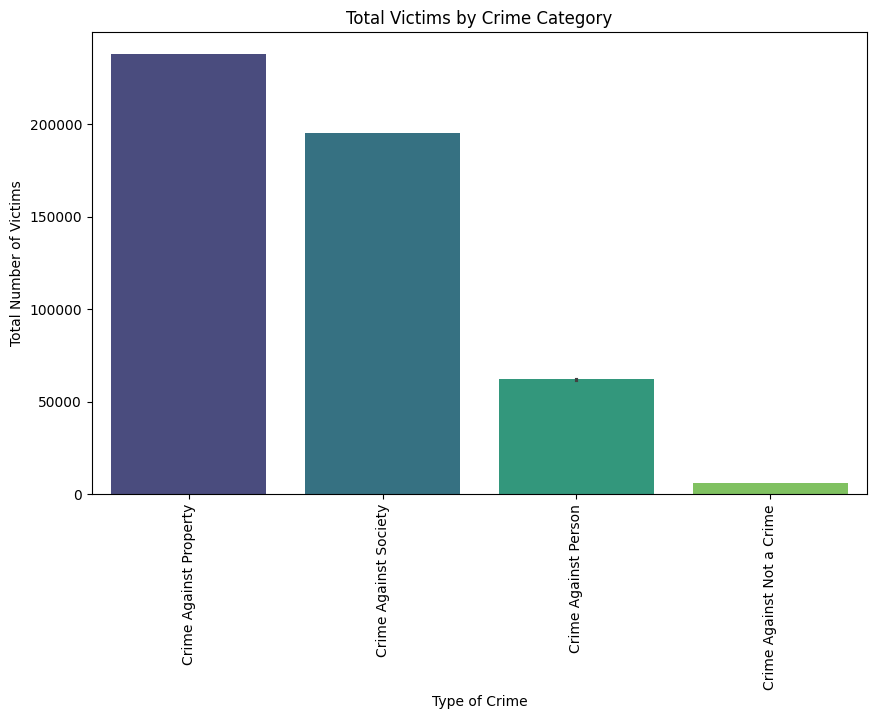

In [31]:


plt.figure(figsize=(10,6))
sns.barplot(x='Crime Name1', y='Victims', data=data_clean, estimator=sum, palette='viridis')
plt.xticks(rotation=90)
plt.title('Total Victims by Crime Category')
plt.xlabel('Type of Crime')
plt.ylabel('Total Number of Victims')
plt.show()

## Bargraph of the Total Victims by Police District

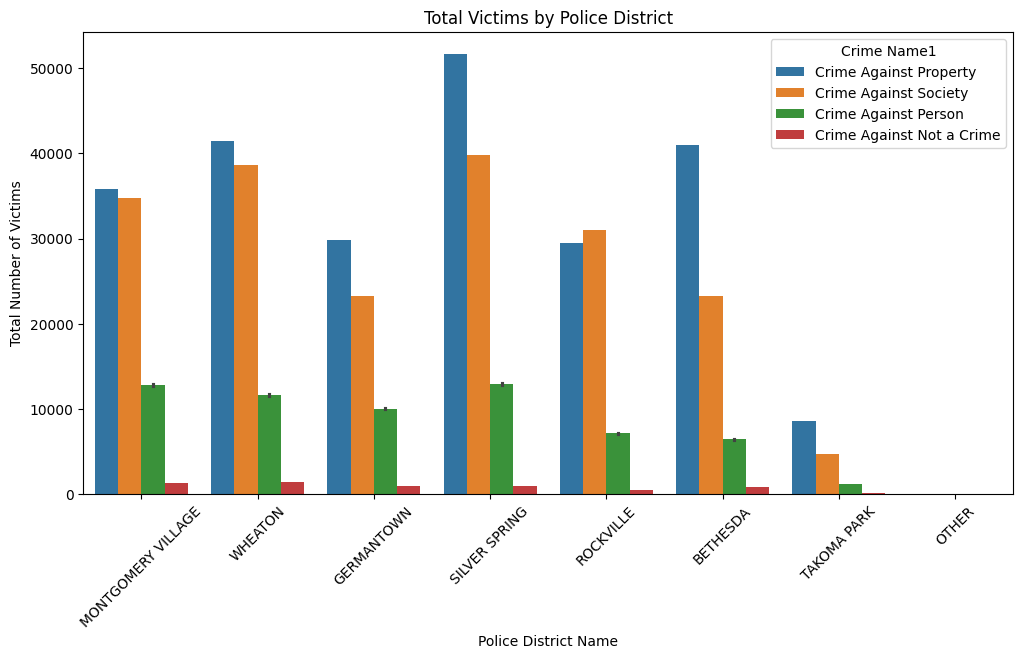

In [32]:

plt.figure(figsize=(12,6))

sns.barplot(x='Police District Name', y='Victims', data=data_clean, estimator=sum, hue='Crime Name1')

plt.xticks(rotation=45)

plt.title('Total Victims by Police District')
plt.xlabel('Police District Name')
plt.ylabel('Total Number of Victims')

plt.show()



The graphs show the most common crime types and the average number of victims by police district. Some districts report higher victim total than others.



# 4. Decision Tree Analysis


In [33]:

from sklearn.model_selection import train_test_split

X = data_encoded.drop('Victims', axis=1)
y = data_encoded['Victims']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [34]:

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Tree depth 5
tree5 = DecisionTreeRegressor(max_depth=5, random_state=42)
tree5.fit(X_train, y_train)

pred5 = tree5.predict(X_test)

mse5 = mean_squared_error(y_test, pred5)
r25 = r2_score(y_test, pred5)

print("Decision Tree Depth 5")
print("MSE:", mse5)
print("R2:", r25)


Decision Tree Depth 5
MSE: 0.029004802449631335
R2: 0.12408961644817795


In [35]:

# Tree depth 10
tree10 = DecisionTreeRegressor(max_depth=10, random_state=42)
tree10.fit(X_train, y_train)

pred10 = tree10.predict(X_test)

mse10 = mean_squared_error(y_test, pred10)
r210 = r2_score(y_test, pred10)

print("Decision Tree Depth 10")
print("MSE:", mse10)
print("R2:", r210)


Decision Tree Depth 10
MSE: 0.02902548142073691
R2: 0.12346513622480815


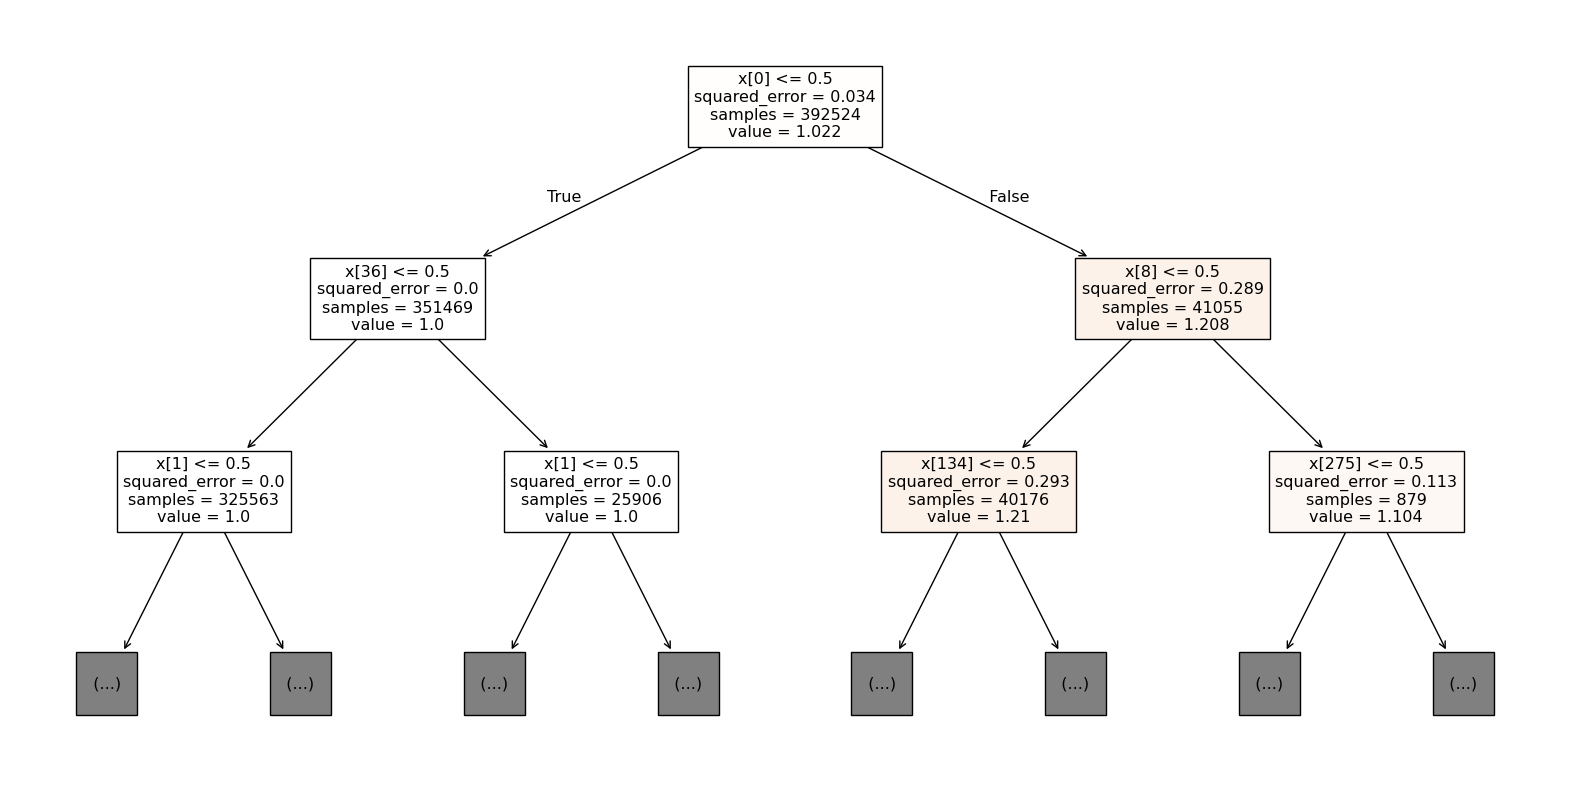

In [36]:

from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(tree5, filled=True, max_depth=2)
plt.show()



# 5. Ensemble Models


## **Random Forest**

In [37]:

from sklearn.ensemble import RandomForestRegressor

rforest = RandomForestRegressor(random_state=42)

rforest.fit(X_train, y_train)

rforest_pred = rforest.predict(X_test)

rforest_mse = mean_squared_error(y_test, rforest_pred)
rforest_r2 = r2_score(y_test, rforest_pred)

print("Random Forest")
print("MSE:", rforest_mse)
print("R2:", rforest_r2)


Random Forest
MSE: 0.029032442990478507
R2: 0.12325490513521287


## **Gradientboosting**

In [38]:

from sklearn.ensemble import GradientBoostingRegressor

gradientb= GradientBoostingRegressor(random_state=42)

gradientb.fit(X_train, y_train)

gradientb_pred = gradientb.predict(X_test)

gradientb_mse = mean_squared_error(y_test, gradientb_pred)
gradientb_r2 = r2_score(y_test, gradientb_pred)

print("Gradient Boosting")
print("MSE:", gradientb_mse)
print("R2:", gradientb_r2)


Gradient Boosting
MSE: 0.028990445480025683
R2: 0.12452317977879424



# **6. Model Evaluation**


In [44]:

results = pd.DataFrame({
    'Model': ['Decision Tree Depth 5',
              'Decision Tree Depth 10',
              'Random Forest',
              'Gradient Boosting'],
    'MSE': [mse5, mse10, rforest_mse, gradientb_mse],
    'R2': [r25, r210, rforest_r2, gradientb_r2]
})

results


,Model,MSE,R2
0,Decision Tree Depth 5,0.029005,0.124090
1,Decision Tree Depth 10,0.029025,0.123465
2,Random Forest,0.029032,0.123255
3,Gradient Boosting,0.028990,0.124523


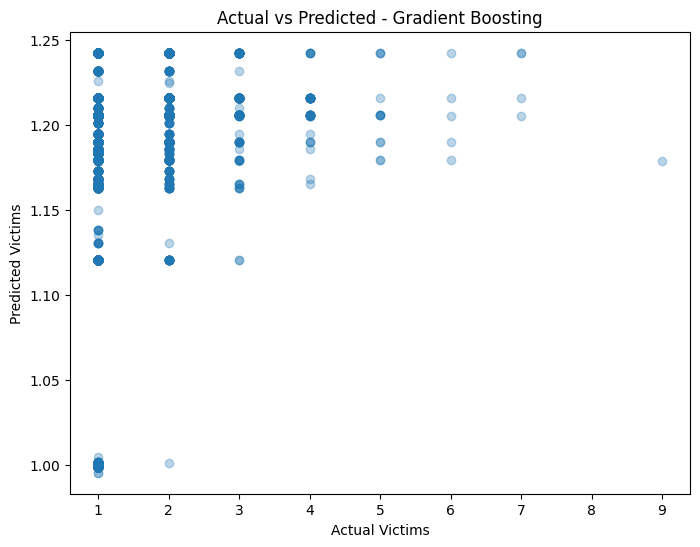

In [45]:

plt.figure(figsize=(8,6))
plt.scatter(y_test, gradientb_pred, alpha=0.3)
plt.xlabel("Actual Victims")
plt.ylabel("Predicted Victims")
plt.title("Actual vs Predicted - Gradient Boosting")
plt.show()



# 7. Feature Importance


In [46]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gradientb.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance.head(10)


,Feature,Importance
0,Crime Name1_Crime Against Person,0.976214
8,Police District Name_TAKOMA PARK,0.005536
134,City_GERMANTOWN,0.004568
6,Police District Name_ROCKVILLE,0.002215
254,City_SILVER SPRING,0.001939
231,City_ROCKVLLE,0.001796
29,City_BEHESDA,0.001737
36,City_BETHESDA,0.001501
56,City_CHEVY CHASE,0.000847
214,City_POTOMAC,0.000587


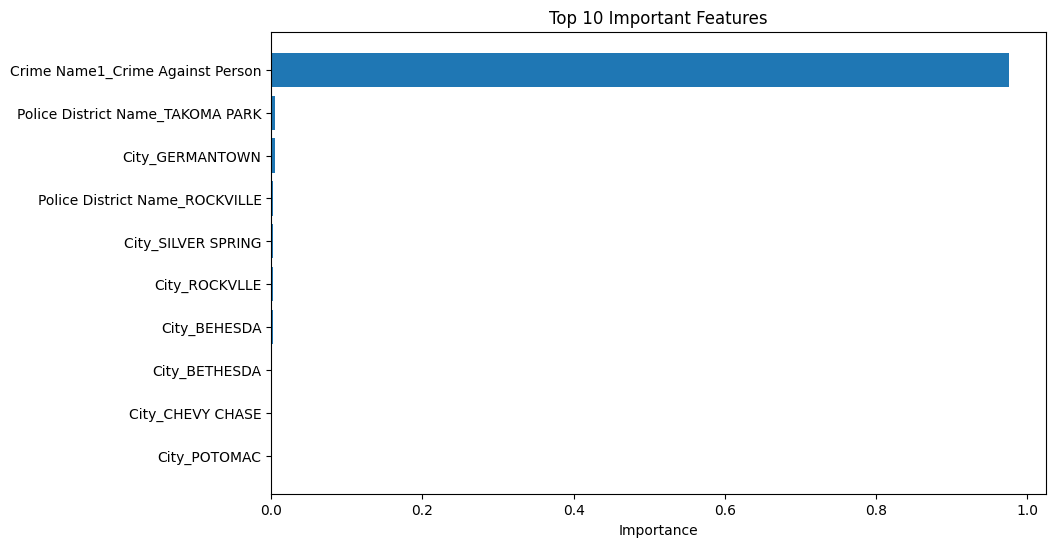

In [47]:

top10 = importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Importance'])
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()



# 8. Final Reflection

In this project, we analyzed Montgomery County crime data to predict the number of victims based on the crime type (Crime Name2), police district, and city. We tested four models, and Gradient Boosting was the champion with the best performance ( R2=0.1257 ,  MSE=0.02921 ), closely followed by Random Forest. An  R2  score of 12.6% is standard and meaningful for crime analysis because human behavior involves a lot of randomness. Our Actual vs Predicted chart shows two main findings: first, infractions labeled 'Crime Against Person' are the most powerful indicators that cause the model to predict multiple victims; second, because the vast majority of real-world crimes in the dataset have exactly one victim, the model plays it safe and groups its predictions horizontally around 1 to minimize total error, making it hard to predict rare incidents with three or more victims. Ultimately, while this model provides an excellent mathematical map of safety risks, adding future data like neighborhood socio-economic factors or security camera locations could help improve its prediction score.